In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("student_performance.csv")

In [6]:
df.head()

,student_id,study_hours,attendance,assignments,previous_marks,participation,result
0,S0001,6.8,51,4,66,4,Pass
1,S0002,2.3,56,10,46,10,Pass
2,S0003,4.8,51,1,62,4,Fail
3,S0004,5.5,51,8,60,9,Pass
4,S0005,4.8,78,9,70,1,Pass


In [7]:
df.tail()

,student_id,study_hours,attendance,assignments,previous_marks,participation,result
495,S0496,3.4,93,9,40,2,Pass
496,S0497,2.7,98,9,62,8,Pass
497,S0498,2.9,71,4,36,4,Fail
498,S0499,9.4,97,1,96,4,Pass
499,S0500,7.3,95,3,85,4,Pass


In [8]:
df.shape

(500, 7)

In [9]:
df.columns

Index(['student_id', 'study_hours', 'attendance', 'assignments',
       'previous_marks', 'participation', 'result'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      500 non-null    object 
 1   study_hours     500 non-null    float64
 2   attendance      500 non-null    int64  
 3   assignments     500 non-null    int64  
 4   previous_marks  500 non-null    int64  
 5   participation   500 non-null    int64  
 6   result          500 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 27.5+ KB


In [11]:
df.describe()

,study_hours,attendance,assignments,previous_marks,participation
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.706000,75.138000,5.106000,68.196000,5.546000
std,2.547537,15.081972,3.109035,19.062222,2.789165
min,1.000000,50.000000,0.000000,35.000000,1.000000
25%,3.500000,62.750000,2.000000,52.000000,3.000000
50%,5.900000,75.000000,5.000000,69.000000,5.000000
75%,7.900000,89.000000,8.000000,84.000000,8.000000
max,10.000000,100.000000,10.000000,100.000000,10.000000


In [15]:
df["result"].value_counts()


result
Pass    436
Fail     64
Name: count, dtype: int64

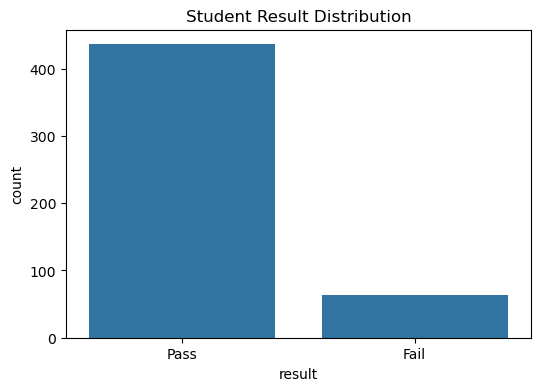

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="result", data=df)
plt.title("Student Result Distribution")
plt.show()

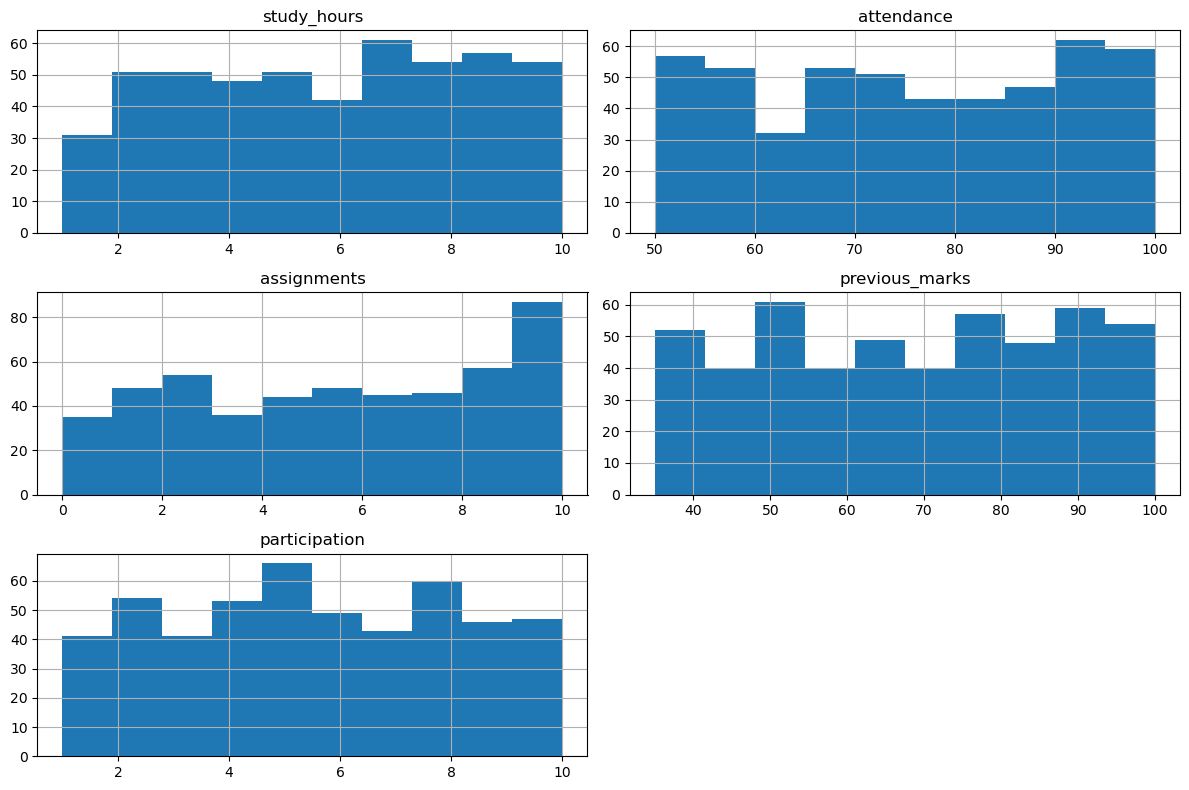

In [17]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [18]:
df["result"] = df["result"].map({"Fail":0,"Pass":1})

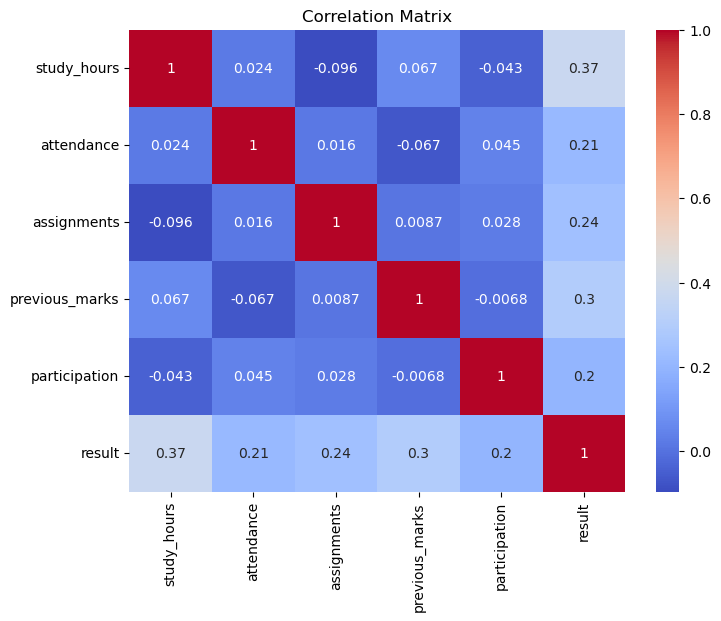

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("student_id", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [20]:
X = df.drop(["student_id", "result"], axis=1)

y = df["result"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
y_pred_lr = lr.predict(X_test)

In [24]:
accuracy_score(y_test, y_pred_lr)

0.97

In [25]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        16
           1       1.00      0.96      0.98        84

    accuracy                           0.97       100
   macro avg       0.92      0.98      0.95       100
weighted avg       0.97      0.97      0.97       100



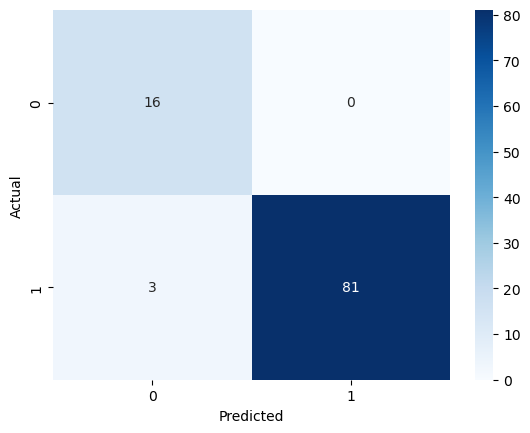

In [26]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
accuracy_score(y_test, y_pred_rf)

0.9

In [30]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62        16
           1       0.91      0.98      0.94        84

    accuracy                           0.90       100
   macro avg       0.86      0.74      0.78       100
weighted avg       0.89      0.90      0.89       100



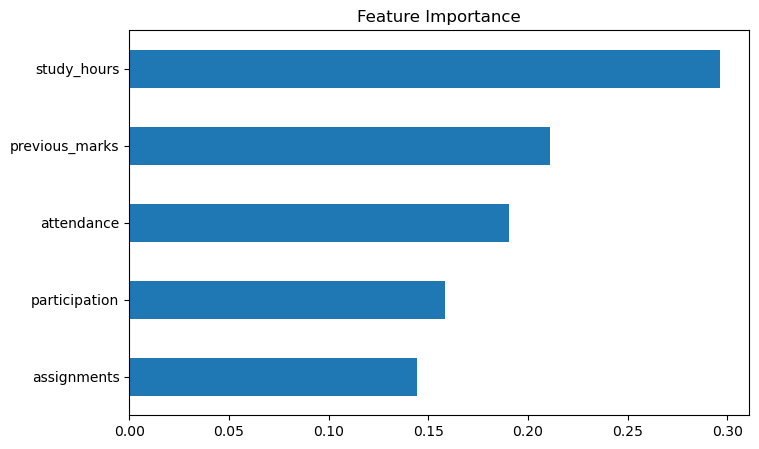

In [31]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [32]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.97
Random Forest Accuracy: 0.9


In [33]:
import joblib

joblib.dump(rf, "student_performance_model.pkl")

['student_performance_model.pkl']

In [34]:
model = joblib.load("student_performance_model.pkl")

In [35]:
print(model)

RandomForestClassifier(random_state=42)


In [36]:
sample = [[6.5, 90, 8, 85, 7]]

prediction = model.predict(sample)

print(prediction)

[1]


d:\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Prediction: Pass


In [44]:
sample = [[5.5, 10, 2, 15, 6]]

prediction = model.predict(sample)

print(prediction)

[0]


d:\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [46]:
if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Prediction: Fail
